In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.colors as colors
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
from matplotlib import rc
from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.cm
import copy
import os
import Prepare
from Prepare import Neutral, SOLPS



casepath = "/data/leuven/379/vsc37950/nt/"
SOLPSpath = "case_input/2MW-5e19/"
case1 = "Outputfile/59012392/"
case2 = "Outputfile/59012401/"
outpath1 = case1 + "data/"
outpath2 = case2 + "data/"
wallpath = casepath + SOLPSpath + "shapedata/wall.txt"
vol_2D = np.loadtxt(fname=casepath + SOLPSpath + "2D_data/vol_2D.dat", skiprows=1)
vol_2D = np.transpose(vol_2D[:, 3].reshape(38, 98))

wall = np.loadtxt(wallpath, skiprows=1)
com_rm = np.load(file=casepath + SOLPSpath + "shapedata/com_rm.npy")
com_zm = np.load(file=casepath + SOLPSpath + "shapedata/com_zm.npy")
x = range(1, 37)
y = range(1, 97)
rs_l = np.loadtxt(fname=casepath + SOLPSpath + "profiles_data/recycled_neutral_flux_D_l.data", skiprows=1)
rs_r = np.loadtxt(fname=casepath + SOLPSpath + "profiles_data/recycled_neutral_flux_D_r.data", skiprows=1)
x_l = [i * 100 for i in rs_l[:, 0]]
x_r = [i * 100 for i in rs_r[:, 0]]

lp_l = [np.sqrt(pow(com_rm[i,19,1] - com_rm[i,19,0], 2) + pow(com_zm[i,19,1] - com_zm[i,19,0], 2)) for i in range(25)]
lp_r = [np.sqrt(pow(com_rm[96 - i,19,1] - com_rm[96 - i,19,0], 2) + pow(com_zm[96 - i,19,1] - com_zm[96 - i,19,0], 2)) for i in range(25)]
dp_l = [sum(lp_l[0:i - 1]) + 0.5 * lp_l[i] for i in range(1,25)]
dp_r = [sum(lp_r[0:i - 1]) + 0.5 * lp_r[i] for i in range(1,25)]
location_x = (com_rm[:,:,0] + com_rm[:,:,1] + com_rm[:,:,2] + com_rm[:,:,3]) / 4
location_y = (com_zm[:,:,0] + com_zm[:,:,1] + com_zm[:,:,2] + com_zm[:,:,3]) / 4

xlim_EAST = [1.30, 1.80]
ylim_EAST = [-1.12, -0.60]
scan_EAST = [3.2e19, 3.6e19, 4e19, 4.6e19, 5e19, 5.4e19, 5.5e19, 5.6e19, 5.8e19]
scan_EAST_str = ["3.2e19", "3.6e19", "4e19", "4.6e19", "5e19", "5.4e19", "5.5e19", "5.6e19", "5.8e19"]
Legend_EAST = ["3.2e19", "3.6e19", "4e19", "4.6e19", "5e19", "5.8e19"]
Neutralcase_Tri = ["59012388/", "59012389/", "59012390/", "59012391/", "59012392/", "59012393/", "59012394/", "59012395/", "59012396/"]
Neutralcase_Ori = ["59012397/", "59012398/", "59012399/", "59012400/", "59012401/", "59012402/", "59012403/", "59012404/", "59012405/"]
Neutralcase_Tri = ["59036801/", "59036802/", "59036803/", "59036804/", "59036805/", "59036806/", "59036807/", "59036808/", "59036809/"]
Neutralcase_Ori = ["59022287/", "59022288/", "59022289/", "59022290/", "59022291/", "59022292/", "59022293/", "59022294/", "59022295/"]

caseused = [0, 4, 8]
allcases = range(9)
legend_array = ["$T_e < 0.5 eV$", "$0.5 eV <= T_e < 1 eV$", "$1 eV <= T_e < 2 eV$", "$2 eV <= T_e < 5 eV$", "$5 eV <= T_e < 10 eV$", "$T_e >= 10 eV$"]

Tri_1 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[0], 0)
Tri_2 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[1], 0)
Tri_3 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[2], 0)
Tri_4 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[3], 0)
Tri_5 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[4], 0)
Tri_6 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[5], 0)
Tri_7 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[6], 0)
Tri_8 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[7], 0)
Tri_9 = Neutral("/data/leuven/379/vsc37950/nt/Outputfile/" + Neutralcase_Tri[8], 0)

Ori_1 = Neutral("/data/leuven/379/vsc37950/NT_old/Outputfile/" + Neutralcase_Ori[0], 0)
Ori_2 = Neutral("/data/leuven/379/vsc37950/NT_old/Outputfile/" + Neutralcase_Ori[1], 0)
Ori_3 = Neutral("/data/leuven/379/vsc37950/NT_old/Outputfile/" + Neutralcase_Ori[2], 0)
Ori_4 = Neutral("/data/leuven/379/vsc37950/NT_old/Outputfile/" + Neutralcase_Ori[3], 0)
Ori_5 = Neutral("/data/leuven/379/vsc37950/NT_old/Outputfile/" + Neutralcase_Ori[4], 0)
Ori_6 = Neutral("/data/leuven/379/vsc37950/NT_old/Outputfile/" + Neutralcase_Ori[5], 0)
Ori_7 = Neutral("/data/leuven/379/vsc37950/NT_old/Outputfile/" + Neutralcase_Ori[6], 0)
Ori_8 = Neutral("/data/leuven/379/vsc37950/NT_old/Outputfile/" + Neutralcase_Ori[7], 0)
Ori_9 = Neutral("/data/leuven/379/vsc37950/NT_old/Outputfile/" + Neutralcase_Ori[8], 0)

EAST_SOLPS_1 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-3.2e19/", 0)
EAST_SOLPS_2 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-3.6e19/", 0)
EAST_SOLPS_3 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-4e19/", 0)
EAST_SOLPS_4 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-4.6e19/", 0)
EAST_SOLPS_5 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-5e19/", 0)
EAST_SOLPS_6 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-5.4e19/", 0)
EAST_SOLPS_7 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-5.5e19/", 0)
EAST_SOLPS_8 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-5.6e19/", 0)
EAST_SOLPS_9 = SOLPS("/data/leuven/379/vsc37950/nt/case_input/2MW-5.8e19/", 0)

EAST_SOLPS = [EAST_SOLPS_1, EAST_SOLPS_2, EAST_SOLPS_3, EAST_SOLPS_4, EAST_SOLPS_5, EAST_SOLPS_6, EAST_SOLPS_7, EAST_SOLPS_8, EAST_SOLPS_9]
EAST_tri = [Tri_1, Tri_2, Tri_3, Tri_4, Tri_5, Tri_6, Tri_7, Tri_8, Tri_9]
EAST_ori = [Ori_1, Ori_2, Ori_3, Ori_4, Ori_5, Ori_6, Ori_7, Ori_8, Ori_9]

for i in range(9):
    EAST_SOLPS[i].SOLPSread()
    EAST_SOLPS[i].Te_matrix_cal()
    EAST_tri[i].set_K_Tri(1)
    EAST_tri[i].Neuread()
    EAST_tri[i].SOLPSMu(EAST_SOLPS[i])
    #EAST[i].Smu_array(EAST_SOLPS[i])
    EAST_tri[i].Smu_fix(EAST_SOLPS[i])
    EAST_tri[i].Smu_sum()

    EAST_ori[i].Neuread()
    EAST_ori[i].SOLPSMu(EAST_SOLPS[i])
    EAST_SOLPS[i].Te_matrix_cal()
    #EAST[i].Smu_array(EAST_SOLPS[i])
    EAST_ori[i].Smu_fix(EAST_SOLPS[i])
    EAST_ori[i].Smu_sum()

save_figures_path = "/data/leuven/379/vsc37950/nt/triangle/EAST/fig/"
if not os.path.exists(save_figures_path):
    os.makedirs(save_figures_path)

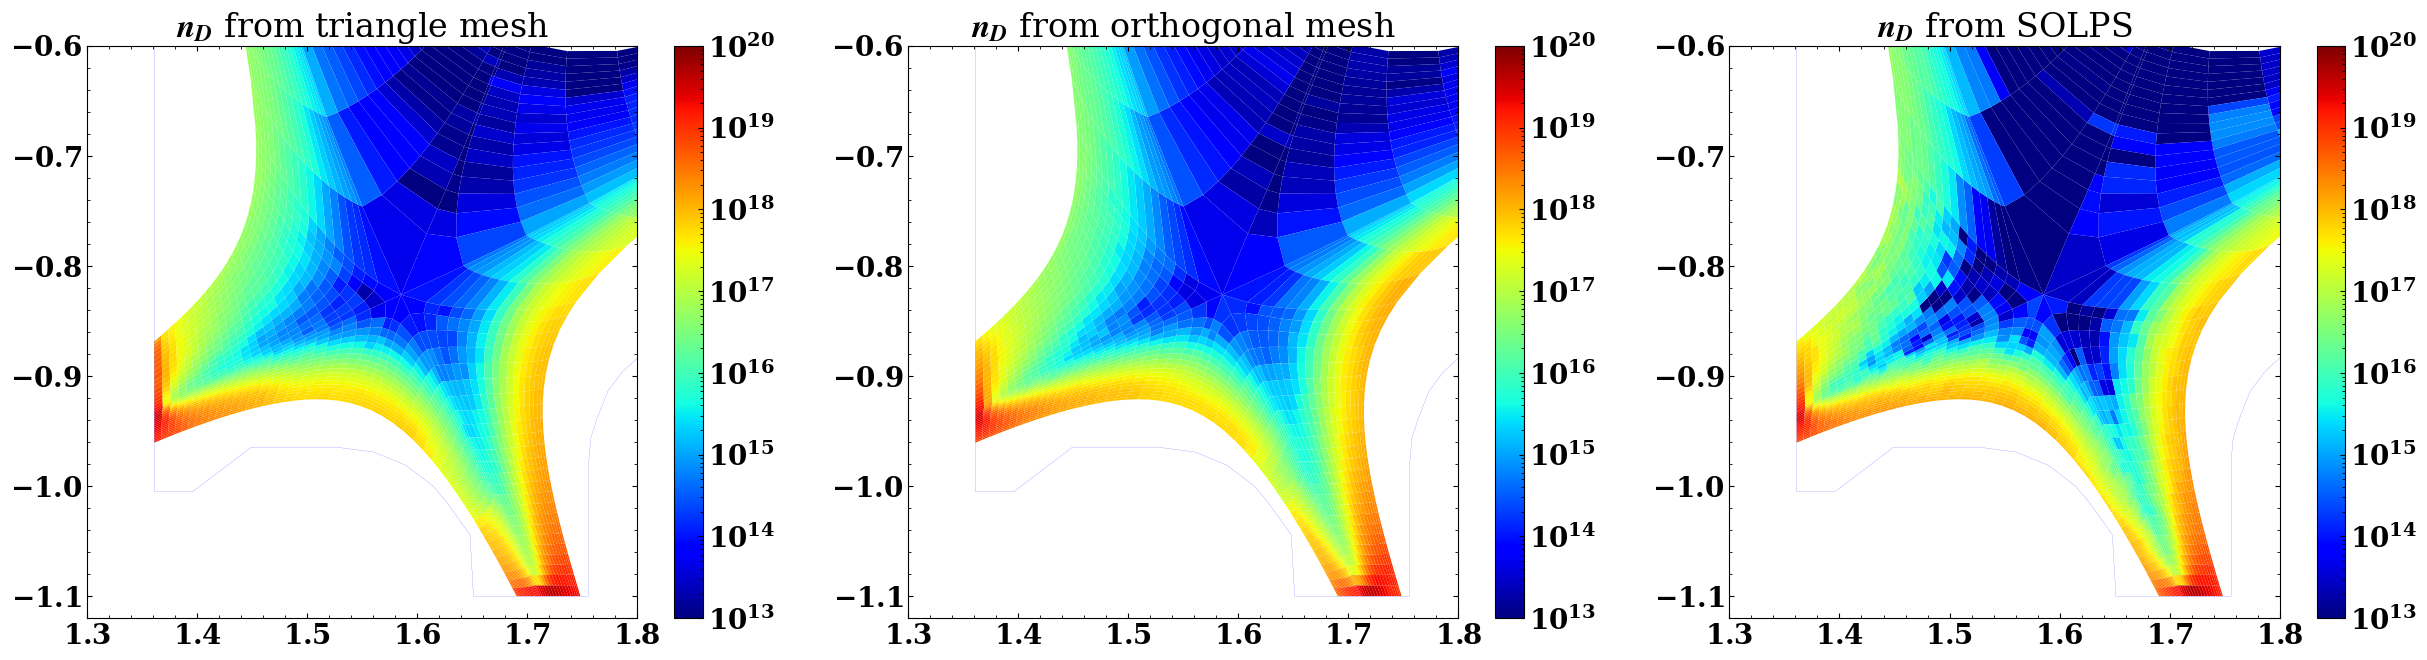

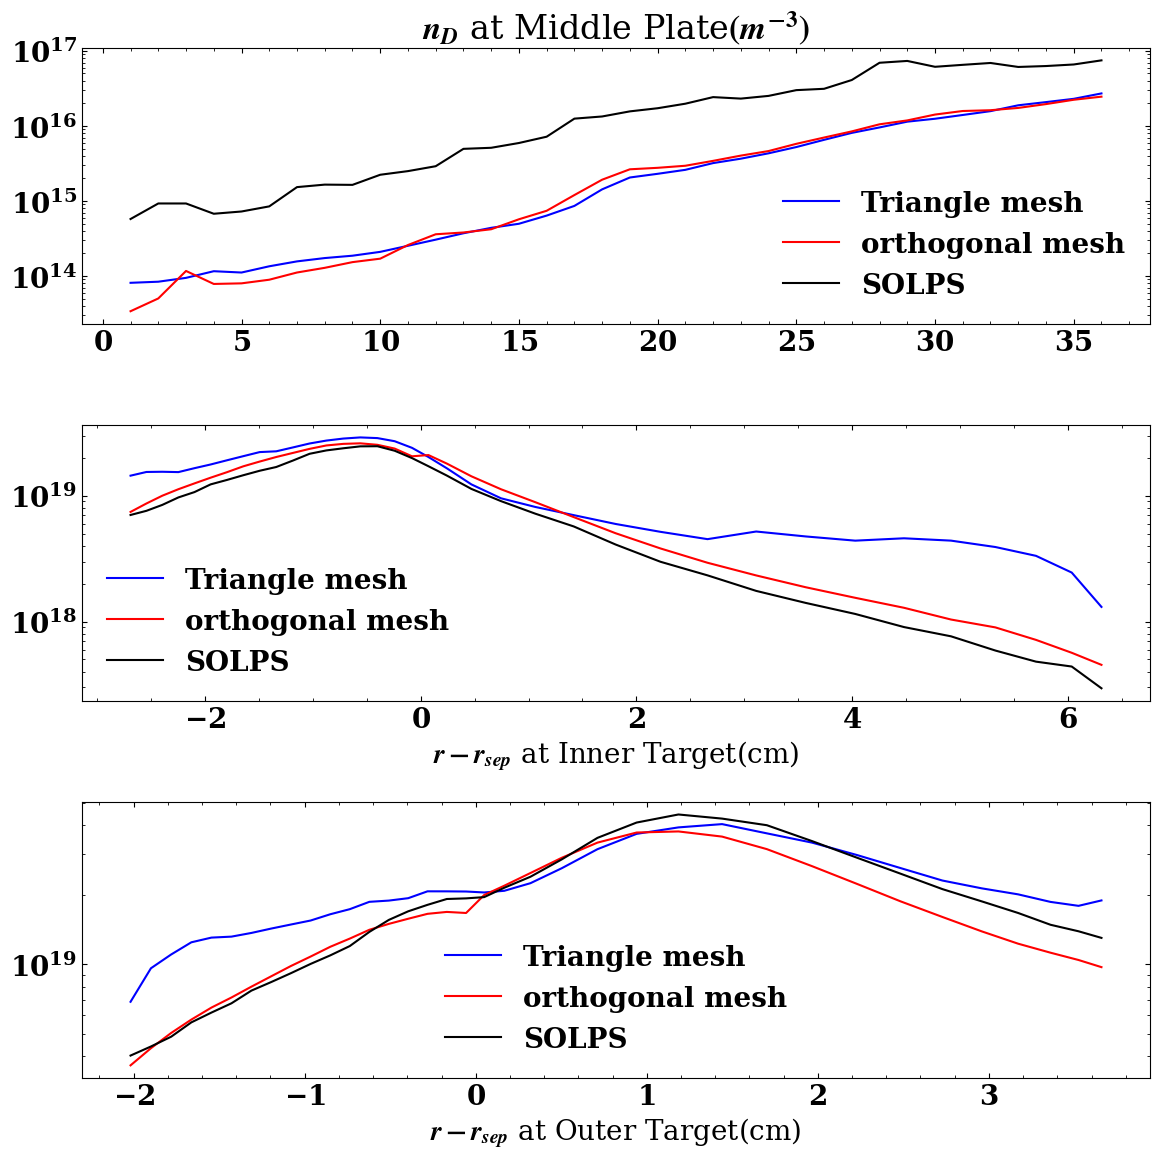

In [2]:

case = 4
n_D_Tri = EAST_tri[case].n_D_0
n_D_old = EAST_ori[case].n_D_0
n_D_SOLPS = EAST_SOLPS[case].n_D_0

patches = []
ixs = 1
com_nx = 96
com_ny = 36
ixe = com_nx+1
iys = 1
iye = com_ny+1
for iy in np.arange(iys, iye):
    for ix in np.arange(ixs, ixe):
        rcol = com_rm[ix, iy, [1, 2, 4, 3]]
        zcol = com_zm[ix, iy, [1, 2, 4, 3]]
        rcol.shape = (4, 1)
        zcol.shape = (4, 1)
        polygon = Polygon(np.column_stack((rcol, zcol)), closed=True)
        patches.append(polygon)

vals1 = np.zeros((ixe-ixs)*(iye-iys))
vals2 = np.zeros((ixe-ixs)*(iye-iys))
vals3 = np.zeros((ixe-ixs)*(iye-iys))

# var2 = var2.reshape(98, 38)

for iy in np.arange(iys, iye):
    for ix in np.arange(ixs, ixe):
        k = (ix-ixs)+(ixe-ixs)*(iy-iys)
        vals1[k] = n_D_Tri[ix, iy]
        vals2[k] = n_D_old[ix, iy]
        vals3[k] = n_D_SOLPS[ix, iy]

p1 = PatchCollection(patches, cmap=mpl.cm.jet, norm=colors.LogNorm())
p1.set_array(np.array(vals1))

p2 = PatchCollection(patches, cmap=mpl.cm.jet, norm=colors.LogNorm())
p2.set_array(np.array(vals2))

p3 = PatchCollection(patches, cmap=mpl.cm.jet, norm=colors.LogNorm())
p3.set_array(np.array(vals3))

# fig,ax = plt.subplots(1)
# fig = plt.figure(figsize=(12,3),dpi = 200)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(25, 7))
ax[0].add_collection(p1)
ax[0].autoscale_view()
ax[0].plot(wall[:, 0], wall[:, 1], color="b", lw=0.1)
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_title("${n}_{D}$ from triangle mesh", )
ax[0].set_xlim(1.30, 1.80)
ax[0].set_ylim(-1.12, -0.60)
# ax[0].text(1.35, -1.15, "Particle Number:\n" +
#           str("%.3e" % Sum_N_D_NeuTran), size=20)
p1.set_clim([1e13, 1e20])
# position = fig.add_axes([0.92, 0.12, 0.015, 0.78])

ax[1].add_collection(p2)
ax[1].autoscale_view()
ax[1].plot(wall[:, 0], wall[:, 1], color="b", lw=0.1)
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_title("${n}_{D}$ from orthogonal mesh")
ax[1].set_xlim(1.30, 1.80)
ax[1].set_ylim(-1.12, -0.60)
# ax[1].text(1.35, -1.15, "Particle Number:\n" +
#           str("%.3e" % Sum_N_D_SOLPS), size=20)
p2.set_clim([1e13, 1e20])

ax[2].add_collection(p3)
ax[2].autoscale_view()
ax[2].plot(wall[:, 0], wall[:, 1], color="b", lw=0.1)
ax[2].set_aspect('equal', adjustable='box')
ax[2].set_title("${n}_{D}$ from SOLPS")
ax[2].set_xlim(1.30, 1.80)
ax[2].set_ylim(-1.12, -0.60)
# ax[2].text(1.35, -1.15, "Particle Number:\n" +
#           str("%.3e" % Sum_N_D_SOLPS), size=20)
p3.set_clim([1e13, 1e20])

fig.colorbar(p1, ax=ax[0])
fig.colorbar(p2, ax=ax[1])
fig.colorbar(p3, ax=ax[2])
# position = fig.add_axes([0.92, 0.12, 0.015, 0.78])
# cd = ax[0].colorbar(p1)
# plt.show()
#fig.savefig("fig/nD_comparison.pdf", dpi=300, bbox_inches='tight')

# Target n_D plot
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 12))
ax[0].semilogy(x, n_D_Tri[63, 1:37], color="b", lw=1.5)
ax[0].semilogy(x, n_D_old[63, 1:37], color="r", lw=1.5)
ax[0].semilogy(x, n_D_SOLPS[63, 1:37], color="k", lw=1.5)
ax[0].set_title("${n}_{D}$ at Middle Plate$({m}^{-3})$")
ax[0].legend(labels=["Triangle mesh", "orthogonal mesh", "SOLPS"], loc='best')

ax[1].semilogy(x_l[1:37], n_D_Tri[1, 1:37], color="b", lw=1.5)
ax[1].semilogy(x_l[1:37], n_D_old[1, 1:37], color="r", lw=1.5)
ax[1].semilogy(x_l[1:37], n_D_SOLPS[1, 1:37], color="k", lw=1.5)
# ax[1].set_title("${n}_{D}$ at Inner Targrt$({m}^{-3})$")
ax[1].set_xlabel("${r-r}_{sep}$ at Inner Target(cm)")
ax[1].legend(labels=["Triangle mesh", "orthogonal mesh", "SOLPS"], loc='best')

ax[2].semilogy(x_r[1:37], n_D_Tri[96, 1:37], color="b", lw=1.5)
ax[2].semilogy(x_r[1:37], n_D_old[96, 1:37], color="r", lw=1.5)
ax[2].semilogy(x_r[1:37], n_D_SOLPS[96, 1:37], color="k", lw=1.5)
# ax[2].set_title("${n}_{D}$ at Outer Targrt$({m}^{-3})$")
ax[2].set_xlabel("${r-r}_{sep}$ at Outer Target(cm)")
ax[2].legend(labels=["Triangle mesh", "orthogonal mesh", "SOLPS"], loc='best')
#fig.savefig("fig/nD_comparison_line.pdf", dpi=300, bbox_inches='tight')

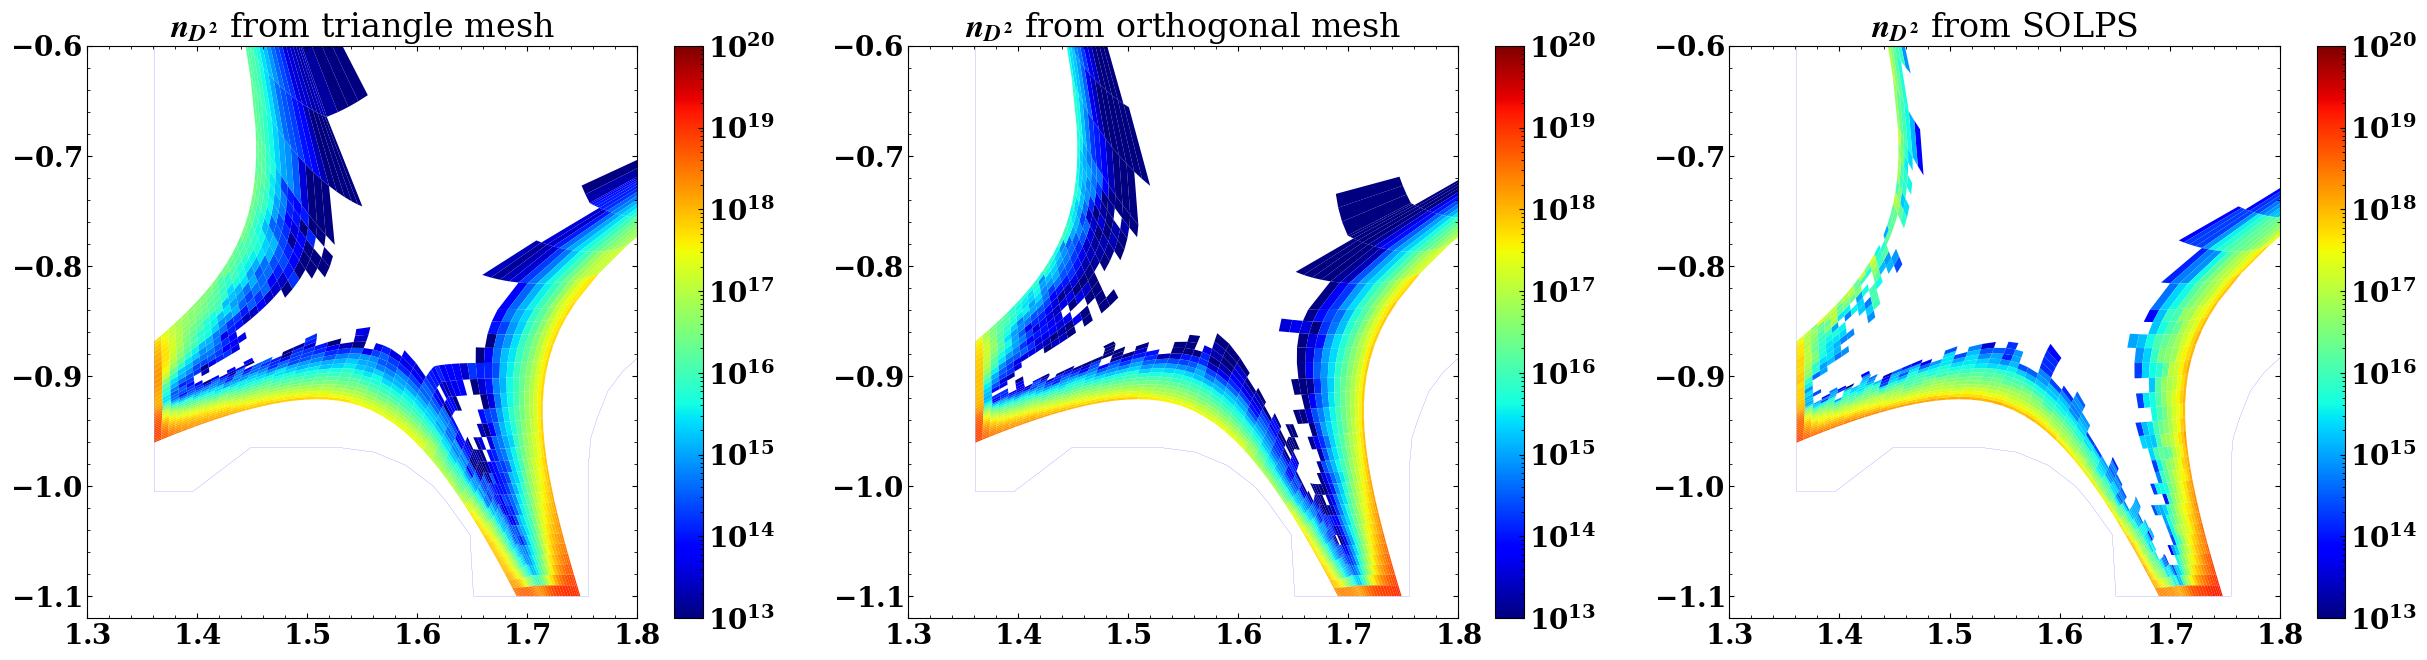

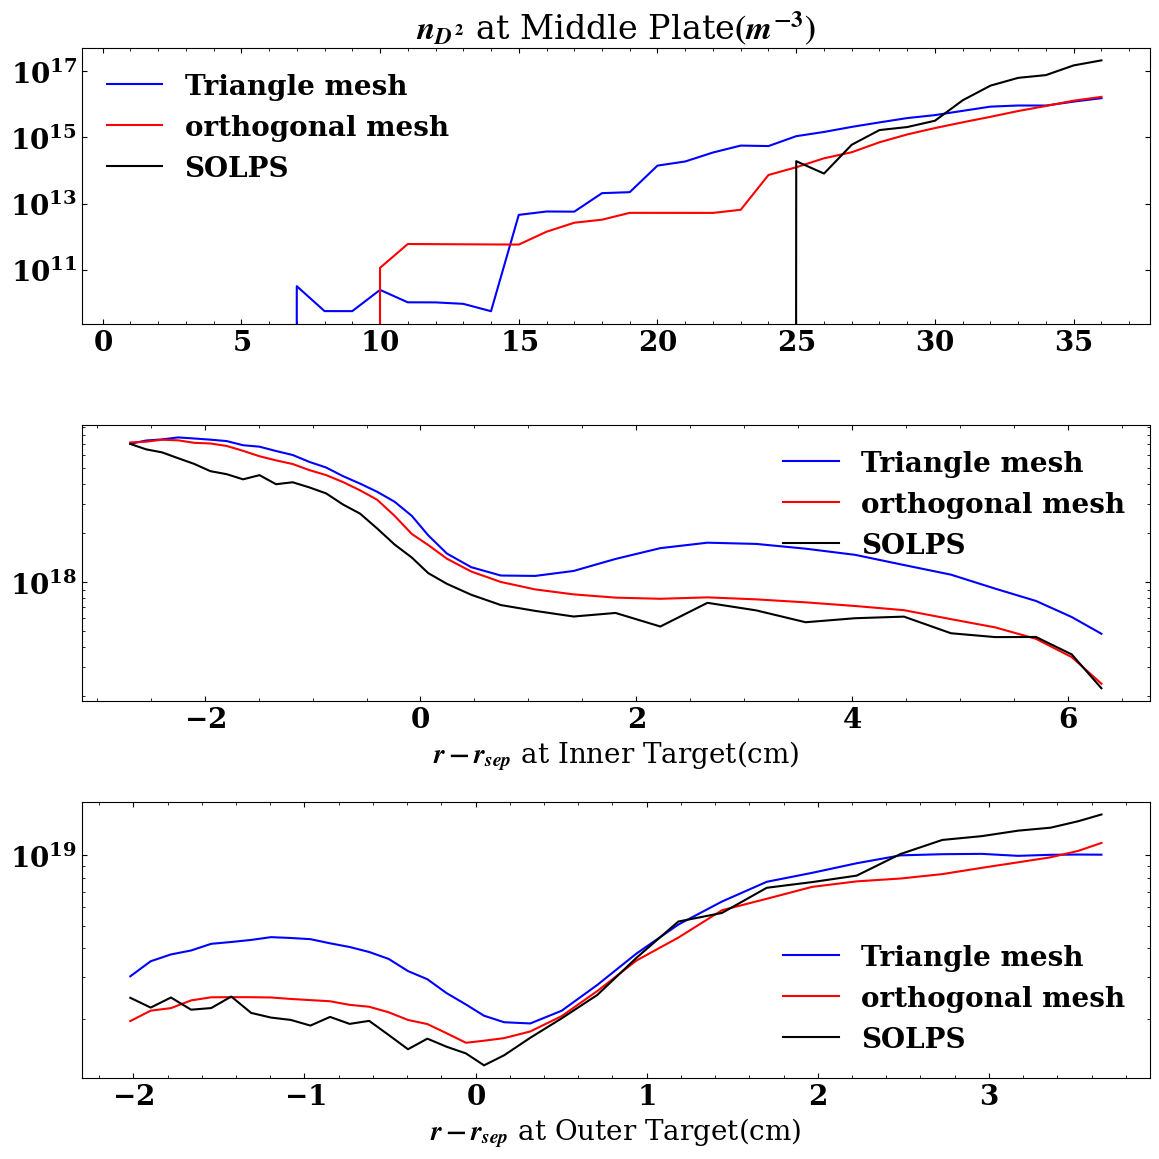

In [3]:
n_D2_SOLPS = np.loadtxt(fname=casepath + SOLPSpath + "2D_data/nDmolecule_2D.data", skiprows=1)
n_D2_SOLPS = np.transpose(n_D2_SOLPS[:, 3].reshape(38, 98))
n_D2_Tri = EAST_tri[case].n_D2_0
n_D2_old = EAST_ori[case].n_D2_0

patches = []
ixs = 1
com_nx = 96
com_ny = 36
ixe = com_nx+1
iys = 1
iye = com_ny+1
for iy in np.arange(iys, iye):
    for ix in np.arange(ixs, ixe):
        rcol = com_rm[ix, iy, [1, 2, 4, 3]]
        zcol = com_zm[ix, iy, [1, 2, 4, 3]]
        rcol.shape = (4, 1)
        zcol.shape = (4, 1)
        polygon = Polygon(np.column_stack((rcol, zcol)), closed=True)
        patches.append(polygon)

vals1 = np.zeros((ixe-ixs)*(iye-iys))
vals2 = np.zeros((ixe-ixs)*(iye-iys))
vals3 = np.zeros((ixe-ixs)*(iye-iys))

# var2 = var2.reshape(98, 38)

for iy in np.arange(iys, iye):
    for ix in np.arange(ixs, ixe):
        k = (ix-ixs)+(ixe-ixs)*(iy-iys)
        vals1[k] = n_D2_Tri[ix, iy]
        vals2[k] = n_D2_old[ix, iy]
        vals3[k] = n_D2_SOLPS[ix, iy]

p1 = PatchCollection(patches, cmap=mpl.cm.jet, norm=colors.LogNorm())
p1.set_array(np.array(vals1))

p2 = PatchCollection(patches, cmap=mpl.cm.jet, norm=colors.LogNorm())
p2.set_array(np.array(vals2))

p3 = PatchCollection(patches, cmap=mpl.cm.jet, norm=colors.LogNorm())
p3.set_array(np.array(vals3))

# fig,ax = plt.subplots(1)
# fig = plt.figure(figsize=(12,3),dpi = 200)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(25, 7))
ax[0].add_collection(p1)
ax[0].autoscale_view()
ax[0].plot(wall[:, 0], wall[:, 1], color="b", lw=0.1)
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_title("${n}_{D^2}$ from triangle mesh", )
ax[0].set_xlim(1.30, 1.80)
ax[0].set_ylim(-1.12, -0.60)
# ax[0].text(1.35, -1.15, "Particle Number:\n" +
#           str("%.3e" % Sum_N_D_NeuTran), size=20)
p1.set_clim([1e13, 1e20])
# position = fig.add_axes([0.92, 0.12, 0.015, 0.78])

ax[1].add_collection(p2)
ax[1].autoscale_view()
ax[1].plot(wall[:, 0], wall[:, 1], color="b", lw=0.1)
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_title("${n}_{D^2}$ from orthogonal mesh")
ax[1].set_xlim(1.30, 1.80)
ax[1].set_ylim(-1.12, -0.60)
# ax[1].text(1.35, -1.15, "Particle Number:\n" +
#           str("%.3e" % Sum_N_D_SOLPS), size=20)
p2.set_clim([1e13, 1e20])

ax[2].add_collection(p3)
ax[2].autoscale_view()
ax[2].plot(wall[:, 0], wall[:, 1], color="b", lw=0.1)
ax[2].set_aspect('equal', adjustable='box')
ax[2].set_title("${n}_{D^2}$ from SOLPS")
ax[2].set_xlim(1.30, 1.80)
ax[2].set_ylim(-1.12, -0.60)
# ax[2].text(1.35, -1.15, "Particle Number:\n" +
#           str("%.3e" % Sum_N_D_SOLPS), size=20)
p3.set_clim([1e13, 1e20])

fig.colorbar(p1, ax=ax[0])
fig.colorbar(p2, ax=ax[1])
fig.colorbar(p3, ax=ax[2])
# position = fig.add_axes([0.92, 0.12, 0.015, 0.78])
# cd = ax[0].colorbar(p1)
# plt.show()
#fig.savefig("fig/nD_comparison.pdf", dpi=300, bbox_inches='tight')

# Target n_D plot
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 12))
ax[0].semilogy(x, n_D2_Tri[63, 1:37], color="b", lw=1.5)
ax[0].semilogy(x, n_D2_old[63, 1:37], color="r", lw=1.5)
ax[0].semilogy(x, n_D2_SOLPS[63, 1:37], color="k", lw=1.5)
ax[0].set_title("${n}_{D^2}$ at Middle Plate$({m}^{-3})$")
ax[0].legend(labels=["Triangle mesh", "orthogonal mesh", "SOLPS"], loc='best')

ax[1].semilogy(x_l[1:37], n_D2_Tri[1, 1:37], color="b", lw=1.5)
ax[1].semilogy(x_l[1:37], n_D2_old[1, 1:37], color="r", lw=1.5)
ax[1].semilogy(x_l[1:37], n_D2_SOLPS[1, 1:37], color="k", lw=1.5)
# ax[1].set_title("${n}_{D}$ at Inner Targrt$({m}^{-3})$")
ax[1].set_xlabel("${r-r}_{sep}$ at Inner Target(cm)")
ax[1].legend(labels=["Triangle mesh", "orthogonal mesh", "SOLPS"], loc='best')

ax[2].semilogy(x_r[1:37], n_D2_Tri[96, 1:37], color="b", lw=1.5)
ax[2].semilogy(x_r[1:37], n_D2_old[96, 1:37], color="r", lw=1.5)
ax[2].semilogy(x_r[1:37], n_D2_SOLPS[96, 1:37], color="k", lw=1.5)
# ax[2].set_title("${n}_{D}$ at Outer Targrt$({m}^{-3})$")
ax[2].set_xlabel("${r-r}_{sep}$ at Outer Target(cm)")
ax[2].legend(labels=["Triangle mesh", "orthogonal mesh", "SOLPS"], loc='best')
#fig.savefig("fig/nD_comparison_line.pdf", dpi=300, bbox_inches='tight')

In [15]:


Switch_Plot = 0
cclim_n_D_0 = [5e13, 5e20]
Value_Scan = [Prepare.EAST_tri[i].n_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "${n}_{{D}^{0}}\,\mathrm{({m}^{-3})}$", "n_D_0.pdf", scan_EAST_str, cclim_n_D_0)
cclim_T_D_0 = [1, 1000]
Value_Scan = [Prepare.EAST_tri[i].T_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "${T}_{{D}^{0}}\,\mathrm{(eV)}$", "T_D_0.pdf", scan_EAST_str, cclim_T_D_0)

cclim_n_e = [5e17, 5e20]
Value_Scan = [Prepare.EAST_SOLPS[i].n_e for i in range(9)]
Prepare.plot_scan(Value_Scan, "${n}_{e}\,\mathrm{({m}^{-3})}$", "n_e.pdf", scan_EAST_str, cclim_n_e)
cclim_T_e = [1, 50]
Value_Scan = [Prepare.EAST_SOLPS[i].T_e for i in range(9)]
Prepare.plot_scan(Value_Scan, "${T}_{e}\,\mathrm{(eV)}$", "T_e.pdf", scan_EAST_str, cclim_T_e)
cclim_T_i = [1, 50]
Value_Scan = [Prepare.EAST_SOLPS[i].T_i for i in range(9)]
Prepare.plot_scan(Value_Scan, "${T}_{i}\,\mathrm{(eV)}$", "T_i.pdf", scan_EAST_str, cclim_T_i)

cclim_Ua = [1, 1e6]
Value_Scan = [Prepare.EAST_SOLPS[i].Ua_Dion_2D for i in range(9)]
Prepare.plot_scan(Value_Scan, "${U}_{a}\,\mathrm{(m/s)}$", "Ua.pdf", scan_EAST_str, cclim_Ua)
Value_Scan = [-Prepare.EAST_SOLPS[i].Ua_Dion_2D for i in range(9)]
Prepare.plot_scan(Value_Scan, "${-U}_{a}\,\mathrm{(m/s)}$", "-Ua.pdf", scan_EAST_str, cclim_Ua)

cclim_n_D2_0 = [1e14, 5e19]
Value_Scan = [Prepare.EAST_tri[i].n_D2_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "${n}_{{D2}^{0}}\,\mathrm{({m}^{-3})}$", "n_D2_0.pdf", Prepare.scan_EAST_str, cclim_n_D2_0)
cclim_n_D2_1 = [1e14, 5e19]
Value_Scan = [Prepare.EAST_tri[i].n_D2_1 for i in range(9)]
Prepare.plot_scan(Value_Scan, "${n}_{{D2}^{1}}\,\mathrm{({m}^{-3})}$", "n_D2_1.pdf", Prepare.scan_EAST_str, cclim_n_D2_1)
cclim_T_D2_0 = [0.2, 50]
Value_Scan = [Prepare.EAST_tri[i].T_D2_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "${T}_{{D2}^{0}}\,\mathrm{(eV)}$", "T_D2_0.pdf", Prepare.scan_EAST_str, cclim_T_D2_0)


cclim_Sn_D_0 = [1e18, 3e21]
Value_Scan = [Prepare.EAST_tri[i].Sn_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n}^{{D}^{0}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_D_0.pdf", Prepare.scan_EAST_str, cclim_Sn_D_0)
cclim_Sn_D_1 = [1e18, 3e21]
Value_Scan = [Prepare.EAST_tri[i].Sn_D_1 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n}^{{D}^{1}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_D_1.pdf", Prepare.scan_EAST_str, cclim_Sn_D_1)


cclim_Sn_Ion_D_0 = [1e17, 1e22]
Value_Scan = [Prepare.EAST_tri[i].Sn_Ion_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n,Ion}^{{D}^{0}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_Ion_D_0.pdf", Prepare.scan_EAST_str, cclim_Sn_Ion_D_0)
cclim_Sn_CX_D_0 = [1e17, 1e23]
Value_Scan = [Prepare.EAST_tri[i].Sn_CX_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n,CX}^{{D}^{0}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_CX_D_0.pdf", Prepare.scan_EAST_str, cclim_Sn_CX_D_0)
cclim_Sn_Rec_D_1 = [1e14, 5e17]
Value_Scan = [Prepare.EAST_tri[i].Sn_Rec_D_1 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n,Rec}^{{D}^{1}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_Rec_D_1.pdf", Prepare.scan_EAST_str, cclim_Sn_Rec_D_1)


cclim_Sn_Ion_D2_0 = [1e17, 5e20]
Value_Scan = [Prepare.EAST_tri[i].Sn_Ion_D2_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n,Ion}^{{D}_{2}^{0}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_Ion_D2_0.pdf", Prepare.scan_EAST_str, cclim_Sn_Ion_D2_0)
cclim_Sn_CX_D2_0 = [1e17, 5e21]
Value_Scan = [Prepare.EAST_tri[i].Sn_CX_D2_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n,CX}^{{D}_{2}^{0}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_CX_D2_0.pdf", Prepare.scan_EAST_str, cclim_Sn_CX_D2_0)
cclim_Sn_Ela_D2_0 = [1e17, 5e22]
Value_Scan = [Prepare.EAST_tri[i].Sn_Ela_D2_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n,Ela}^{{D}_{2}^{0}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_Ela_D2_0.pdf", Prepare.scan_EAST_str, cclim_Sn_Ela_D2_0)
cclim_Sn_Diss1_D2_0 = [1e17, 5e20]
Value_Scan = [Prepare.EAST_tri[i].Sn_Diss1_D2_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n,Diss1}^{{D}_{2}^{0}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_Diss1_D2_0.pdf", Prepare.scan_EAST_str, cclim_Sn_Diss1_D2_0)
cclim_Sn_Diss2_D2_0 = [1e17, 5e20]
Value_Scan = [Prepare.EAST_tri[i].Sn_Diss2_D2_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n,Diss2}^{{D}_{2}^{0}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_Diss2_D2_0.pdf", Prepare.scan_EAST_str, cclim_Sn_Diss2_D2_0)
cclim_Sn_DS1_D2_1 = [1e17, 5e20]
Value_Scan = [Prepare.EAST_tri[i].Sn_DS1_D2_1 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n,DS1}^{{D}_{2}^{+}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_DS1_D2_1.pdf", Prepare.scan_EAST_str, cclim_Sn_DS1_D2_1)
cclim_Sn_DS2_D2_1 = [1e17, 5e20]
Value_Scan = [Prepare.EAST_tri[i].Sn_DS2_D2_1 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n,DS2}^{{D}_{2}^{+}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_DS2_D2_1.pdf", Prepare.scan_EAST_str, cclim_Sn_DS2_D2_1)
cclim_Sn_DS3_D2_1 = [1e17, 5e20]
Value_Scan = [Prepare.EAST_tri[i].Sn_DS3_D2_1 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n,DS3}^{{D}_{2}^{+}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_DS3_D2_1.pdf", Prepare.scan_EAST_str, cclim_Sn_DS3_D2_1)
cclim_Sn_DS4_D2_1 = [1e17, 5e20]
Value_Scan = [Prepare.EAST_tri[i].Sn_DS4_D2_1 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{n,DS4}^{{D}_{2}^{+}}\,\mathrm{({m}^{-3}{s}^{-1})}$", "Sn_DS4_D2_1.pdf", Prepare.scan_EAST_str, cclim_Sn_DS4_D2_1)


cclim_Srad_Ion_D_0 = [1e4, 5e7]
Value_Scan = [Prepare.EAST_tri[i].Pra_Ion_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{rad,Ion}^{{D}^{0}}\,\mathrm{(W{m}^{-3})}$", "Srad_Ion_D_0.pdf", Prepare.scan_EAST_str, cclim_Srad_Ion_D_0)
cclim_Srad_CX_D_0 = [1e3, 1e8]
Value_Scan = [Prepare.EAST_tri[i].Pra_CX_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{rad,CX}^{{D}^{0}}\,\mathrm{(W{m}^{-3})}$", "Srad_CX_D_0.pdf", Prepare.scan_EAST_str, cclim_Srad_CX_D_0)
cclim_Srad_Rec_D_1 = [1e3, 1e8]
Value_Scan = [Prepare.EAST_tri[i].Pra_Rec_D_1 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{rad,Rec}^{{D}^{1}}\,\mathrm{(W{m}^{-3})}$", "Srad_Rec_D_1.pdf", Prepare.scan_EAST_str, cclim_Srad_Rec_D_1)


cclim_SE_Ion_D_0 = [1e3, 1e8]
Value_Scan = [Prepare.EAST_tri[i].SE_Ion_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{E,Ion}^{{D}^{0}}\,\mathrm{(W{m}^{-3})}$", "SE_Ion_D_0.pdf", Prepare.scan_EAST_str, cclim_SE_Ion_D_0)
cclim_SE_CX_D_0 = [1e3, 1e8]
Value_Scan = [-Prepare.EAST_tri[i].SE_CX_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{E,CX}^{{D}^{0}}\,\mathrm{(W{m}^{-3})}$", "SE_CX_D_0.pdf", Prepare.scan_EAST_str, cclim_SE_CX_D_0)
cclim_SE_Rec_D_1 = [1e3, 1e8]
Value_Scan = [-Prepare.EAST_tri[i].SE_Rec_D_1 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{E,Rec}^{{D}^{1}}\,\mathrm{(W{m}^{-3})}$", "-SE_Rec_D_1.pdf", Prepare.scan_EAST_str, cclim_SE_Rec_D_1)
cclim_SE_CX_D2_0 = [1e3, 1e8]
Value_Scan = [-Prepare.EAST_tri[i].SE_CX_D2_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{E,CX}^{{D}_{2}^{0}}\,\mathrm{(W{m}^{-3})}$", "SE_CX_D2_0.pdf", Prepare.scan_EAST_str, cclim_SE_CX_D2_0)
cclim_SE_Ela_D2_0 = [1e3, 1e8]
Value_Scan = [-Prepare.EAST_tri[i].SE_Ela_D2_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{E,Ela}^{{D}_{2}^{0}}\,\mathrm{(W{m}^{-3})}$", "SE_Ela_D2_0.pdf", Prepare.scan_EAST_str, cclim_SE_Ela_D2_0)


cclim_Smu_Ion_D_0 = [1e-3, 5]
Value_Scan = [Prepare.EAST_tri[i].Smu_Ion_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{M,Ion}^{{D}^{0}}\,\mathrm{(N{m}^{-3})}$", "Smu_Ion_D_0.pdf", Prepare.scan_EAST_str, cclim_Smu_Ion_D_0)
cclim_Smu_CX_D_0 = [1e-3, 5]
Value_Scan = [Prepare.EAST_tri[i].Smu_CX_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{M,CX}^{{D}^{0}}\,\mathrm{(N{m}^{-3})}$", "Smu_CX_D_0.pdf", Prepare.scan_EAST_str, cclim_Smu_CX_D_0)
Value_Scan = [Prepare.EAST_tri[i].Smu1_CX_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{M,CX}^{{D}^{0}}\,\mathrm{(N{m}^{-3})}$", "Smu1_CX_D_0.pdf", Prepare.scan_EAST_str, cclim_Smu_CX_D_0)
Value_Scan = [Prepare.EAST_tri[i].Smu2_CX_D_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{M,CX}^{{D}^{0}}\,\mathrm{(N{m}^{-3})}$", "Smu2_CX_D_0.pdf", Prepare.scan_EAST_str, cclim_Smu_CX_D_0)
cclim_Smu_Rec_D_1 = [1e-3, 5]
Value_Scan = [Prepare.EAST_tri[i].Smu_Rec_D_1 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{M,Rec}^{{D}^{1}}\,\mathrm{(N{m}^{-3})}$", "Smu_Rec_D_1.pdf", Prepare.scan_EAST_str, cclim_Smu_Rec_D_1)
cclim_Smu_CX_D2_0 = [1e-3, 5]
Value_Scan = [Prepare.EAST_tri[i].Smu_CX_D2_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{M,CX}^{{D}_{2}^{0}}\,\mathrm{(N{m}^{-3})}$", "Smu_CX_D2_0.pdf", Prepare.scan_EAST_str, cclim_Smu_CX_D2_0)
cclim_Smu_Ela_D2_0 = [1e-3, 5]
Value_Scan = [Prepare.EAST_tri[i].Smu_Ela_D2_0 for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{M,Ela}^{{D}_{2}^{0}}\,\mathrm{(N{m}^{-3})}$", "Smu_Ela_D2_0.pdf", Prepare.scan_EAST_str, cclim_Smu_Ela_D2_0)

cclim_Smu_Ion_D_0 = [1e-3, 5]
Value_Scan = [Prepare.EAST_tri[i].Smu_Ion_D_0_Ua for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{M,Ion}^{{D}^{0}}\,\mathrm{(N{m}^{-3})}$", "Smu_Ion_D_0_Ua.pdf", Prepare.scan_EAST_str, cclim_Smu_Ion_D_0)
cclim_Smu_CX_D_0 = [1e-3, 5]
Value_Scan = [Prepare.EAST_tri[i].Smu_CX_D_0_Ua for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{M,CX}^{{D}^{0}}\,\mathrm{(N{m}^{-3})}$", "Smu_CX_D_0_Ua.pdf", Prepare.scan_EAST_str, cclim_Smu_CX_D_0)
cclim_Smu_Rec_D_1 = [1e-3, 5]
Value_Scan = [Prepare.EAST_tri[i].Smu_Rec_D_1_Ua for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{M,Rec}^{{D}^{1}}\,\mathrm{(N{m}^{-3})}$", "Smu_Rec_D_1_Ua.pdf", Prepare.scan_EAST_str, cclim_Smu_Rec_D_1)
cclim_Smu_CX_D2_0 = [1e-3, 5]
Value_Scan = [Prepare.EAST_tri[i].Smu_CX_D2_0_Ua for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{M,CX}^{{D}_{2}^{0}}\,\mathrm{(N{m}^{-3})}$", "Smu_CX_D2_0_Ua.pdf", Prepare.scan_EAST_str, cclim_Smu_CX_D2_0)
cclim_Smu_Ela_D2_0 = [1e-3, 5]
Value_Scan = [Prepare.EAST_tri[i].Smu_Ela_D2_0_Ua for i in range(9)]
Prepare.plot_scan(Value_Scan, "$S_{M,Ela}^{{D}_{2}^{0}}\,\mathrm{(N{m}^{-3})}$", "Smu_Ela_D2_0_Ua.pdf", Prepare.scan_EAST_str, cclim_Smu_Ela_D2_0)

<>:4: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:11: SyntaxWarning: invalid escape sequence '\,'
<>:14: SyntaxWarning: invalid escape sequence '\,'
<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:21: SyntaxWarning: invalid escape sequence '\,'
<>:23: SyntaxWarning: invalid escape sequence '\,'
<>:27: SyntaxWarning: invalid escape sequence '\,'
<>:30: SyntaxWarning: invalid escape sequence '\,'
<>:33: SyntaxWarning: invalid escape sequence '\,'
<>:38: SyntaxWarning: invalid escape sequence '\,'
<>:41: SyntaxWarning: invalid escape sequence '\,'
<>:46: SyntaxWarning: invalid escape sequence '\,'
<>:49: SyntaxWarning: invalid escape sequence '\,'
<>:52: SyntaxWarning: invalid escape sequence '\,'
<>:57: SyntaxWarning: invalid escape sequence '\,'
<>:60: SyntaxWarning: invalid escape sequence '\,'
<>:63: SyntaxWarning: invalid escape sequence '\,'
<>:66: SyntaxWarning: invalid escape sequence '\,'
<>:69: SyntaxWarning: invalid esc

AttributeError: module 'Prepare' has no attribute 'EAST_tri'

In [ ]:

cclim_B = [0.5, 1.5]
Value_Scan1 = [EAST_tri[i].Bx for i in range(9)]
Value_Scan2 = [EAST_tri[i].By for i in range(9)]
Value_Scan3 = [EAST_tri[i].B for i in range(9)]
Prepare.row_scan(Value_Scan1, Value_Scan2, Value_Scan3, "$B$", "B" + ".pdf", scan_EAST_str, cclim_B)

cclim_V = [1, 100000]
Value_Scan1 = [EAST_tri[i].V_CX_Ion_Be * EAST_tri[i].Bx for i in range(9)]
Value_Scan2 = [EAST_tri[i].V_CX_Ion_Be * EAST_tri[i].By for i in range(9)]
Value_Scan3 = [np.abs(EAST_tri[i].V_CX_Ion_Be) for i in range(9)]
Prepare.row_scan(Value_Scan1, Value_Scan2, Value_Scan3, "${V}^{CX}_{D^+}\,\mathrm{(ms^{-1})}$", "V_CX_1_Be" + ".pdf", scan_EAST_str, cclim_V)
Value_Scan1 = [EAST_tri[i].V_CX_Neu_Be for i in range(9)]
Value_Scan2 = [EAST_tri[i].V_CX_Neu_Be for i in range(9)]
Value_Scan3 = [np.abs(EAST_tri[i].V_CX_Neu_Be) for i in range(9)]
Prepare.row_scan(Value_Scan1, Value_Scan2, Value_Scan3, "${V}^{CX}_{D^+}\,\mathrm{(ms^{-1})}$", "V_CX_0_Be" + ".pdf", scan_EAST_str, cclim_V)
Value_Scan1 = [EAST_tri[i].V_CX_Ion_Af * EAST_tri[i].Bx for i in range(9)]
Value_Scan2 = [EAST_tri[i].V_CX_Ion_Af * EAST_tri[i].By for i in range(9)]
Value_Scan3 = [np.abs(EAST_tri[i].V_CX_Ion_Af) for i in range(9)]
Prepare.row_scan(Value_Scan1, Value_Scan2, Value_Scan3, "${V}^{CX}_{D^+}\,\mathrm{(ms^{-1})}$", "V_CX_1_Af" + ".pdf", scan_EAST_str, cclim_V)
Value_Scan1 = [EAST_tri[i].V_CX_Neu_Af * EAST_tri[i].Bx for i in range(9)]
Value_Scan2 = [EAST_tri[i].V_CX_Neu_Af * EAST_tri[i].By for i in range(9)]
Value_Scan3 = [np.abs(EAST_tri[i].V_CX_Neu_Af) for i in range(9)]
Prepare.row_scan(Value_Scan1, Value_Scan2, Value_Scan3, "${V}^{CX}_{D^+}\,\mathrm{(ms^{-1})}$", "V_CX_0_Af" + ".pdf", scan_EAST_str, cclim_V)
Value_Scan1 = [EAST_tri[i].Vx_Ua for i in range(9)]
Value_Scan2 = [EAST_tri[i].Vy_Ua for i in range(9)]
Value_Scan3 = [np.abs(EAST_tri[i].V_Ua) for i in range(9)]
Prepare.row_scan(Value_Scan1, Value_Scan2, Value_Scan3, "${V}^{parallel}_{D^+}\,\mathrm{(ms^{-1})}$", "V_Ua" + ".pdf", scan_EAST_str, cclim_V)

Value_Scan1 = [EAST_tri[i].Vx_D_1 for i in range(9)]
Value_Scan2 = [EAST_tri[i].Vy_D_1 for i in range(9)]
Value_Scan3 = [np.abs(EAST_tri[i].V_D_1) for i in range(9)]
Prepare.row_scan(Value_Scan1, Value_Scan2, Value_Scan3, "${V}^{parallel}_{D^+}\,\mathrm{(ms^{-1})}$", "V_Ua_stat_2" + ".pdf", scan_EAST_str, cclim_V)

Value_Scan1 = [EAST_tri[i].Vx_D_0 for i in range(9)]
Value_Scan2 = [EAST_tri[i].Vy_D_0 for i in range(9)]
Value_Scan3 = [np.sqrt(EAST_tri[i].Vx_D_0*EAST_tri[i].Vx_D_0 + EAST_tri[i].Vy_D_0*EAST_tri[i].Vy_D_0) for i in range(9)]
Prepare.row_scan(Value_Scan1, Value_Scan2, Value_Scan3, "${V}_{D^0}\,\mathrm{(ms^{-1})}$", "V_D_0_" + ".pdf", scan_EAST_str, cclim_V)



Value_Scan1 = [EAST_tri[i].Vx_CX_Neu_Delta  for i in range(9)]
Value_Scan2 = [EAST_tri[i].Vy_CX_Neu_Delta  for i in range(9)]
Value_Scan3 = [np.abs(EAST_tri[i].V_CX_Neu_Delta) for i in range(9)]
Prepare.row_scan(Value_Scan1, Value_Scan2, Value_Scan3, "${V}^{CX}_{D^0}\,\mathrm{(ms^{-1})}$", "V_CX_0_bianhua" + ".pdf", scan_EAST_str, cclim_V)
Value_Scan1 = [EAST_tri[i].Vx_CX_Ion_Delta - EAST_tri[i].V_CX_Ion_Delta * EAST_tri[i].Bx for i in range(9)]
Value_Scan2 = [EAST_tri[i].Vy_CX_Ion_Delta - EAST_tri[i].V_CX_Ion_Delta * EAST_tri[i].By for i in range(9)]
Value_Scan3 = [np.abs(EAST_tri[i].V_CX_Ion_Delta) for i in range(9)]
Prepare.row_scan(Value_Scan1, Value_Scan2, Value_Scan3, "${V}^{CX}_{D^+}\,\mathrm{(ms^{-1})}$", "V_CX_1_bianhua_radial" + ".pdf", scan_EAST_str, cclim_V)
Value_Scan1 = [EAST_tri[i].V_CX_Ion_Delta * EAST_tri[i].Bx for i in range(9)]
Value_Scan2 = [EAST_tri[i].V_CX_Ion_Delta * EAST_tri[i].By for i in range(9)]
Value_Scan3 = [np.abs(EAST_tri[i].V_CX_Ion_Delta) for i in range(9)]
Prepare.row_scan(Value_Scan1, Value_Scan2, Value_Scan3, "${V}^{CX}_{D^+}\,\mathrm{(ms^{-1})}$", "V_CX_1_bianhua_proidal" + ".pdf", scan_EAST_str, cclim_V)

: 

: 

In [ ]:
case = [1, 2, 3, 4, 5, 6, 7, 8, 9]

time_old = [19+54/60, 28+34/60, 28+47/60, 29+41/60, 22+25/60, 35+55/60, 39+32/60, 46+30/60, 58+23/60]
time_new = [12+29/60, 10+43/60, 9+27/60, 8+51/60, 9+51/60, 16+40/60, 18+6/60, 20+55/60, 25+32/60]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))
ax.plot(scan_EAST_str, time_new, color="b", lw=1.5)
ax.plot(scan_EAST_str, time_old, color="r", lw=1.5)
ax.legend(labels=["Triangle mesh", "old code"], loc='best')
ax.set_xlabel("density at core")
ax.set_ylabel("CPU time of codes(min)")
ax.set_title("Runtime for tracking 500000 particles")

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import matplotlib.colors as colors

# ==========================================
# 1. 读取 EIRENE 原始数据文件
# ==========================================
print("正在读取网格与数据文件...")

# 1. 读取节点坐标 (fort.33)
# 假设前两列分别是 R (X) 和 Z (Y) 坐标
# 如果文件有表头，可以加上 skiprows=1
with open("/data/leuven/379/vsc37950/nt/case_input/2MW-3.2e19/solps_output/fort.33", "r") as f:
    raw_text = f.read()

# 2. 魔法操作：用 split() 把所有数字拆成一个一维的长列表
# split() 会自动把所有空格、换行符全部吃掉，无视“每排4个”的限制
all_numbers = raw_text.split()

# 3. 按照你描述的顺序，逐个提取（提取的同时转成浮点数/整数）

# 第 1 个数字是点的数量 (转成整数)
n_nodes = int(all_numbers[0])
print(f"成功读取！网格节点总数 N = {n_nodes}")

# 紧接着的 n_nodes 个数字是 R 坐标 (转成 numpy 数组方便后续画图)
R_nodes = np.array([float(x) for x in all_numbers[1 : 1 + n_nodes]])/100

# 再紧接着的 n_nodes 个数字是 Z 坐标
Z_nodes = np.array([float(x) for x in all_numbers[1 + n_nodes : 1 + 2 * n_nodes]])/100

# 简单验证一下读取是否正确
print(f"R 坐标读取了 {len(R_nodes)} 个，前三个是: {R_nodes[:3]}")
print(f"Z 坐标读取了 {len(Z_nodes)} 个，前三个是: {Z_nodes[:3]}")

# 2. 读取三角形连接矩阵 (fort.34)
# 假设文件里每行代表一个三角形，前三列是组成它的三个节点编号
# 注意：必须指定 dtype=int，否则会以浮点数读取，无法作为索引
elements = np.loadtxt("/data/leuven/379/vsc37950/nt/case_input/2MW-3.2e19/solps_output/fort.34", dtype=int, skiprows=1)

# 【核心天坑】：EIRENE(Fortran)索引从1开始，Python从0开始，必须全体减1！
triangles = elements[:, 1:4] - 1  

# 3. 读取物理量数据 (fort.35)
# 假设这里面存的是中性粒子密度 (n_D)
# 如果 fort.35 有多列，请把 0 改成你需要的列索引（比如 data[:, 2]）
data = np.loadtxt("/data/leuven/379/vsc37950/nt/case_input/2MW-3.2e19/solps_output/fort.35", skiprows=1)
n_D_Tri = data[:, 0] if data.ndim > 1 else data  # 兼容单列或多列格式

print(f"读取完毕！共 {len(R_nodes)} 个节点，{len(triangles)} 个三角形。")

# ==========================================
# 2. 构建 matplotlib 的三角网格对象
# ==========================================
triangulation = mtri.Triangulation(R_nodes, Z_nodes, triangles)

# （可选）过滤掉密度为 0 或极小的无效网格，防止取对数时报错
mask = (n_D_Tri <= 1e-10)
triangulation.set_mask(mask)

# ==========================================
# 3. 开始绘制高质量伪彩图
# ==========================================
# 设置全局字体为学术衬线字体
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Times New Roman']

fig, ax = plt.subplots(figsize=(10, 13), dpi=300)

# 使用 tripcolor 绘制三角形中心数据
# norm=colors.LogNorm() 开启对数坐标，非常适合画跨度极大的密度分布
tc = ax.tripcolor(triangulation, 
                  facecolors=Prepare.EAST_tri[4].n_D_0_Tri, 
                  cmap='jet', 
                  norm=colors.LogNorm(vmin=1e13, vmax=1e20), # 请根据你的实际密度上下限修改
                  edgecolors='none',  # 如果网格太密，建议设为 'none' 不画黑线；如果网格稀疏，可以设为 'k'
                  linewidth=0.1)

# 设置坐标轴与比例
ax.set_aspect('equal', adjustable='box') # 保持物理比例 1:1
# ax.set_xlim(1.30, 1.80) # 如果需要局部放大，取消这行的注释
# ax.set_ylim(-1.12, -0.60)

# 添加标签与标题
ax.set_xlabel("R [m]", fontsize=14)
ax.set_ylabel("Z [m]", fontsize=14)
ax.set_title("Neutral Density ${n}_{D}$", fontsize=16)

# 添加 Colorbar
cbar = fig.colorbar(tc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Density [m$^{-3}$]", fontsize=14)

# 保存与显示
fig.savefig("nD_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

: 

In [ ]:
fig, ax = plt.subplots(figsize=(10, 13), dpi=300)

# 使用 tripcolor 绘制三角形中心数据
# norm=colors.LogNorm() 开启对数坐标，非常适合画跨度极大的密度分布
tc = ax.tripcolor(triangulation, 
                  facecolors=Prepare.EAST_tri[4].n_D2_0_Tri, 
                  cmap='jet', 
                  norm=colors.LogNorm(vmin=1e13, vmax=1e20), # 请根据你的实际密度上下限修改
                  edgecolors='none',  # 如果网格太密，建议设为 'none' 不画黑线；如果网格稀疏，可以设为 'k'
                  linewidth=0.1)

# 设置坐标轴与比例
ax.set_aspect('equal', adjustable='box') # 保持物理比例 1:1
# ax.set_xlim(1.30, 1.80) # 如果需要局部放大，取消这行的注释
# ax.set_ylim(-1.12, -0.60)

# 添加标签与标题
ax.set_xlabel("R [m]", fontsize=14)
ax.set_ylabel("Z [m]", fontsize=14)
ax.set_title("Neutral Density ${n}_{D}$", fontsize=16)

# 添加 Colorbar
cbar = fig.colorbar(tc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Density [m$^{-3}$]", fontsize=14)

# 保存与显示
fig.savefig("nD_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

: 